# Introduction
In this notebook we will see the necessary stages required to get a descent score on the **Titanic: Machine Learning from Disaster** dataset. We will be going through all the steps and not try not to skip out on any important stage. While getting into any problem which involves AI, we generally need to go through the following stages.
- Problem Definition
- Hypothesis Generation
- Data Extraction
- Data Exploration and Transformation
- Model Building

# Problem Definition:

![Titanic](https://media.snl.no/media/26195/article_topimage_Titanic-Cobh-Harbour-1912.JPG)

Out of all the aforementioned stages, this is probably the simplest one, since most of the times the problem definition is given and what you are pursuing. For example, for this challenge, the problem definition is _"Given a set of passenger attributes, can we come up with a system which makes prediction whether a passenger (who's attributes will not be known to the system) has survived or not."_

# Hypothesis Generation:

In this step we would have to be a little creative and try think outside the box. We would have to come up with different hypothesis for the cases for survival of this tragedy. We may have some intuition such as, _females and children is more likely to be prioritized for rescue, Survival rate should increate as the fare increases (Since the higher paying passengers may be more important)_ and so on. For more, we would have to dive deep into the dataset itself. Whatever hypothesis we come up with in this phase, our task would be to validate them during the **Data Exploration** phase.<br/>



# Data Extraction

Well, we wont have to do much in this stage, since the data is provided by Kaggle in a CSV format. So in this case, data extraction is as simple as reading a csv file. In real life scenario however, this is one of the most tedious stages of them all, we may have to work on scrappers and alot of automation pipelines.

# Imports

**For Exploratory Data Analysis**

In [1]:
import os
import sys
import warnings

import scipy
import numpy as np
import pandas as pd

import matplotlib
import seaborn as sns
import matplotlib.pyplot as plt

import sklearn
from sklearn.preprocessing import LabelEncoder

%matplotlib inline
warnings.filterwarnings('ignore')

Now, this is not a must, but it's a good practise to check what versions of the different modules we will be working with.

In [2]:
print('-'*30,'VERSIONS','-'*30)
print('Python version: {}'.format(sys.version))
for name, module in [('Pandas', pd),
                     ('Matplotlib', matplotlib),
                     ('Numpy', np),
                     ('Seaborn', sns),
                     ('Scikit-Learn', sklearn),
                     ('Scipy', scipy)]:
    print('{} version: {}'.format(name, module.__version__))

------------------------------ VERSIONS ------------------------------
Python version: 3.7.6 | packaged by conda-forge | (default, Mar 23 2020, 23:03:20) 
[GCC 7.3.0]
Pandas version: 1.0.3
Matplotlib version: 3.2.1
Numpy version: 1.18.1
Seaborn version: 0.10.0
Scikit-Learn version: 0.23.1
Scipy version: 1.4.1


In [3]:
# Setting matplotlib constants
matplotlib.style.use('ggplot')
sns.set_style('whitegrid')

## Reading the datasets

In [4]:
data_dir = '/kaggle/input/titanic'
train_fn = 'train.csv'
test_fn = 'test.csv'

train = pd.read_csv(os.path.join(data_dir, train_fn))
test = pd.read_csv(os.path.join(data_dir, test_fn))

for dataset, fn in [(train, train_fn), (test, test_fn)]:
    dataset.name = fn.split('.')[0]

# Basic Lookup

Now that we have read the dataset, lets take a look at it with the following pandas methods ```DataFrame.head()```, ```DataFrame.describe()``` and ```DataFrame.info()```. These don't do much in terms of finding insights, but they sure help finding inconsistencies of the top. Like number of missing values, data types etc.

In [5]:
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [6]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


# Data Exploration

[Data Exploration](https://en.wikipedia.org/wiki/Data_exploration) is probably the most important step in any data science project. In this stage the dataset will go through a series of transformation (depending on the problem of course). This step can be divided into following substages:
- **Variable Identification** (Dependent, Independent, Categorical, Continuous etc)
- **Handling Missing values** (Looking for missing values and then taking appropriate measures)
- **Univariate Analysis** (Continuous Variable Analysis, Categorical Variable Analysis)
- **Bivariate Analysis** (Study of the empirical relationships among variables)
- **Outlier Treatment**

There are some great kernels for the Titanic Dataset, which has way more detailed approach to Data Exploration. I will link some of those notebooks at the end.

# Looking for missing values

For now lets just check if we have some missing values in our dataset, remember to check in both train as well as test dataset. Don't worry it's not cheating, we're just making sure that we are not missing any field, and if so we are taking proper measure to deal with them. If we were to alter our model based on the test dataset that would have been cheating. :)

In [8]:
for dataset in [train, test]:
    print('{} dataset'.format(dataset.name).upper())
    print('-'*20)
    print(dataset.isnull().sum())
    print('='*20)

TRAIN DATASET
--------------------
PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64
TEST DATASET
--------------------
PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


# Variable Identification

In this step our goal is to identify different kinds of variables present in our dataset and proceed accordingly. For example, **Dependent** and **Independent** variables:

### Dependent Variable
The variable that depends on other factors that are measured. These variables are expected to change as a result of an experimental manipulation of the independent variable(s).
### Independent Variable
The variable that is stable and unaffected by the other variables you are trying to measure. If refers to the condition of an experiment that is systematically manipulated by the investigator.

Simply, The **independent variable** is the **cause**. Its value is independent of other variables in your study. Whereas, the **dependent variable** is the **effect**. Its value depends on changes in the independent variable.

### Categorical Variable
A categorical variable (sometimes called a nominal variable) is one that has two or more categories, but there is no intrinsic ordering to the categories. For example, gender is a categorical variable having two categories (male and female) and there is no intrinsic ordering to the categories.

### Ordinal Variable
An ordinal variable is similar to a categorical variable. The difference between the two is that there is a clear ordering of the categories. For example, suppose you have a variable, economic status, with three categories (low, medium and high). In addition to being able to classify people into these three categories, you can order the categories as low, medium and high.




Refer to this [article](https://www.scribbr.com/methodology/independent-and-dependent-variables/) if you want to read about this topic. For distinction between **categorical**, **ordinal** and **numerical** variables refer to this [page](https://stats.idre.ucla.edu/other/mult-pkg/whatstat/what-is-the-difference-between-categorical-ordinal-and-numerical-variables/)

In [9]:
dtypes = ['int64','float64','object']
for d in dtypes:
    print('\n','*'*20,'{} type Attributes'.format(d.upper()), '*'*20, end='\n\n')
    print(list(train.select_dtypes(d).columns), end='\n\n')
    for field in list(train.select_dtypes(d).columns):
        print('{} ==> {}'.format(field, 'CONTINUOUS' if train[field].value_counts().count() > 10 else 'CATEGORICAL'))


 ******************** INT64 type Attributes ********************

['PassengerId', 'Survived', 'Pclass', 'SibSp', 'Parch']

PassengerId ==> CONTINUOUS
Survived ==> CATEGORICAL
Pclass ==> CATEGORICAL
SibSp ==> CATEGORICAL
Parch ==> CATEGORICAL

 ******************** FLOAT64 type Attributes ********************

['Age', 'Fare']

Age ==> CONTINUOUS
Fare ==> CONTINUOUS

 ******************** OBJECT type Attributes ********************

['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']

Name ==> CONTINUOUS
Sex ==> CATEGORICAL
Ticket ==> CONTINUOUS
Cabin ==> CONTINUOUS
Embarked ==> CATEGORICAL


# Handling Missing Values

Depending on the situation there are mainly three types of missing values:
* **Missing Completely at Random (MCAR)**
* **Missing at Random (MAR)**
* **Missing Not at Random (MNAR)**

But there are many ways of handling missing values, For example
#### Imputation:
Imputation is a procedure for entering a value for specific data item where the response is missing or unusable. ([source](https://stats.oecd.org/glossary/detail.asp?ID=3462))
#### Dropping:
In this method we simply drop the rows containing missing data. Although this method is very straaight forward, but now very practical since if we're missing some attribute's entry for majority of the rows then dropping the rows would just result in a loss of information.

For imputation this following simplication works out (most of the time)
* Imputation
    * Continuous Variable
        * Mean
        * Median
        * Regression
    * Categorical Variable
        * Mode
        * Classification

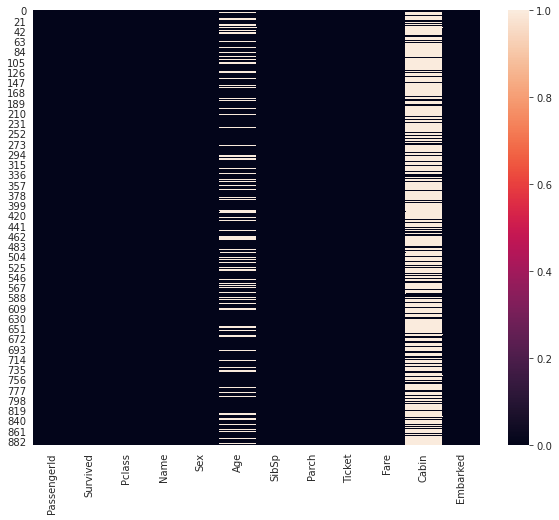

In [10]:
# One very easy way to visualize the missing fields is by plotting the heatmap
plt.figure(figsize=(10,8))
sns.heatmap(train.isnull())

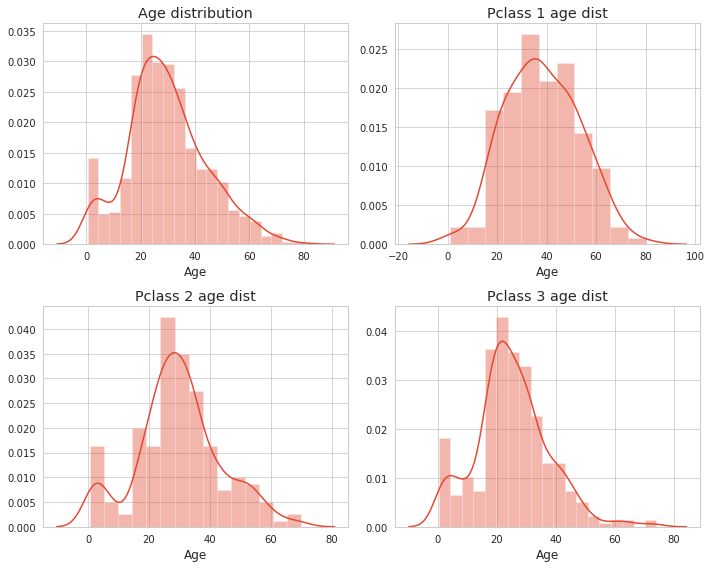

In [11]:
# Age distributions
_, a = plt.subplots(nrows=2, ncols=2, figsize=(10,8))
a[0][0].set_title('Age distribution')
a[0][1].set_title('Pclass 1 age dist')
a[1][0].set_title('Pclass 2 age dist')
a[1][1].set_title('Pclass 3 age dist')
sns.distplot(train['Age'], ax=a[0][0])
sns.distplot(train[train['Pclass']==1]['Age'], ax=a[0][1])
sns.distplot(train[train['Pclass']==2]['Age'], ax=a[1][0])
sns.distplot(train[train['Pclass']==3]['Age'], ax=a[1][1])
plt.tight_layout()

In [12]:
# Appplying changes to both datasets
for dataset in [train, test]:
    dataset.Age = dataset[['Age', 'Pclass']].apply(
        lambda x: dataset[dataset.Pclass == x[1]].Age.median() if pd.isnull(x[0]) else x[0],
        axis=1
    )

## Inputing Embarked Column
The Embarked column had the least number of missing values, so we're simply going to impute this with the mode (Since this is a categorical attribute)

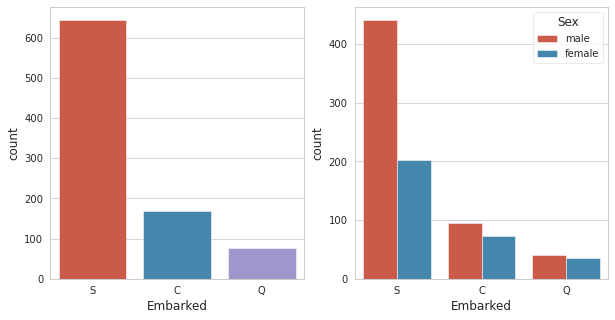

In [13]:

# Lets take a look at these values first
_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))
sns.countplot(x='Embarked', data=train, ax=ax[0])
sns.countplot(x='Embarked', data=train, hue='Sex', ax=ax[1])

In [14]:
# Imputing embarked with mode

for dataset in [train, test]:
    dataset.Embarked.fillna(dataset.Embarked.mode()[0],
                            inplace=True)
    
# Imputing fare with median
for dataset in [train, test]:
    dataset.Fare.fillna(dataset.Fare.median(),
                        inplace=True)

Number of passengers with cabin data: 204
Number of passengers without cabin data: 687


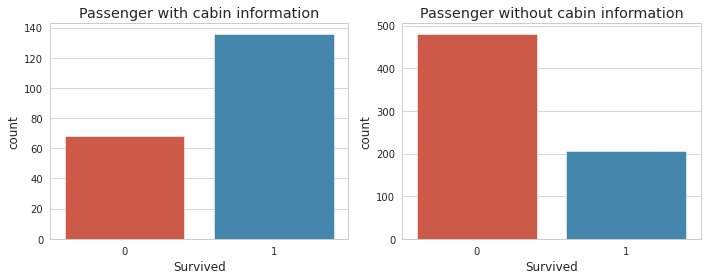

In [15]:
# Now lets see what effect the column cabin has on the passenger's survivavility

num_passenger_with_cabin_data = train[~pd.isna(train.Cabin)].shape[0]
num_passenger_without_cabin_data = train.shape[0] - num_passenger_with_cabin_data

print('Number of passengers with cabin data: {}\nNumber of passengers without cabin data: {}'.format(
    num_passenger_with_cabin_data, num_passenger_without_cabin_data
))

# Passengers with cabin data who survived vs. perished

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10, 4))

sns.countplot(train[~pd.isna(train.Cabin)].Survived, ax=ax[0])
sns.countplot(train[pd.isna(train.Cabin)].Survived, ax=ax[1])

ax[0].set_title('Passenger with cabin information')
ax[1].set_title('Passenger without cabin information')

plt.tight_layout()

So, it seems like the presence of cabin attribute plays a very significant role to the final outcome. Lets create a column indicating wheather cabin data is present or not.

In [16]:
for dataset in [train, test]:
    dataset['IsCabin'] = dataset['Cabin'].apply(
        lambda x: 0 if pd.isnull(x) else 1
    )

Text(0.5, 1.0, 'Test dataset null values')

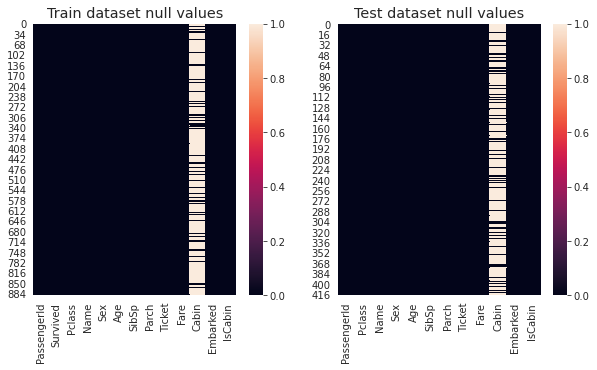

In [17]:
# Lets take a look at the null values now

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

sns.heatmap(train.isnull(), ax=ax[0])
ax[0].set_title('Train dataset null values')

sns.heatmap(test.isnull(), ax=ax[1])
ax[1].set_title('Test dataset null values')

# Feature Engineering

The most dynamic step in any data science project, Feature Engineering is when we generate attributes based on the acquired dataset. This requires alot of knowledge in the domain and well understanding of the dataset we're working with.

_**Defn**: Feature engineering is the process of transformaing raw data into features that better represent the underlying problem to predictive models, resulting in improved model accuracy on unseen data._

Refer to the [this](https://machinelearningmastery.com/discover-feature-engineering-how-to-engineer-features-and-how-to-get-good-at-it/) article to learn more about the importance of feature engineering. There are some great kernels for this dataset which goes into Feature Engineering in much more details. I will add a link to some of them below.<br/>

For now, we are just creating the following attributes<br/>
`FamilySize`, `IsAlone`, `Title`, `FareBin`, `AgeBin`

In [18]:
# In this stage we are creating new features such as FamilySize, IsAlone etc

for dataset in [train, test]:
    dataset['FamilySize'] = dataset['SibSp'] + dataset['Parch'] + 1
    dataset['IsAlone'] = 1
    # Passengers who have a familysize greater then 1 is definitely not alone
    dataset['IsAlone'].loc[dataset['FamilySize']>1] = 0
    
    # Creating title attribute
    dataset['Title'] = dataset['Name'].apply(
        lambda x: x.split(',')[1].split('.')[0].strip()
    )
    
    # Binning fare attribute values
    dataset['FareBin'] = pd.qcut(dataset['Fare'], 4)
    
    # Binning age values into 4 segments
    dataset['AgeBin'] = pd.cut(dataset['Age'].astype(int), 5)
    
# Taking a look at the newly created title attribute
train.Title.value_counts()

Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
the Countess      1
Mme               1
Capt              1
Don               1
Jonkheer          1
Sir               1
Lady              1
Ms                1
Name: Title, dtype: int64

### Binning

_[Defn](https://en.wikipedia.org/wiki/Data_binning):_ **Binning** or **Bucketing** is a data pre-processing technique used to reduce the effects of minor observations errors. The original data values which fall into a given small interval, a bin, are replaced by a value representative of that interval, often the central value. It is a form of quantization.

In the following part, we are going to apply binning. Binning or discretization is the process of transforming numerical variables into categorical counterparts. An example is to bin values for Age into categories such as 20-39, 40-59, 60-79 etc. In our case we will be binning less frequent titles to "Others".<br/>
Binning may improve accuracy of the predictive models by replacing the noise or non-linearity. Finally, binning allows easy identification of outliers, invalid and missing values of numerical variables. ([source](https://www.saedsayad.com/binning.htm))

In [19]:
# There are many uncommon titles, so we can bin the less frequent titles

train_title_names = (train.Title.value_counts() < 10)
test_title_names = (test.Title.value_counts() < 10)

# All titles which occurs less than 10 times will now be replaced by 'Others'
train.Title = train.Title.apply(
    lambda x: 'Others' if train_title_names.loc[x] else x
)
test.Title = test.Title.apply(
    lambda x: 'Others' if test_title_names.loc[x] else x
)

In [20]:
# Now lets apply label encoding to the non numeric fields, we are using label encoder and not one hot encoding
# to preserve the ordinality among the variables

le = LabelEncoder()

for dataset in [train, test]:
    dataset.Sex = le.fit_transform(dataset.Sex)
    dataset.Embarked = le.fit_transform(dataset.Embarked)
    dataset.Title = le.fit_transform(dataset.Title)
    dataset.AgeBin = le.fit_transform(dataset.AgeBin)
    dataset.FareBin = le.fit_transform(dataset.FareBin)

# Univariate Analysis

Univariate analysis is the simplest form of analyzing data. "Uni" means "one", so in other words your data has only one variable. It doesn't deal with causes or relationships (unlike regression) and it's major purpose is to describe; it takes data, summarizes that data and finds patterns in the data.<br/>
A variable in univariate analysis is just a condition or subset that your data falls into. You can think of it as a "category". For example, the analysis might look at a variable of "age" or it might look at "height" or "weight". However, it doesn't look at more than one variable at a time otherwise it becomes bivariate analysis (or in the case of 3 or more variables it would be called multivariate analysis).<br/>
Read more from the [source](https://www.statisticshowto.com/univariate/)

Text(0.5, 1.0, 'Male (1) vs. Female (0) Count')

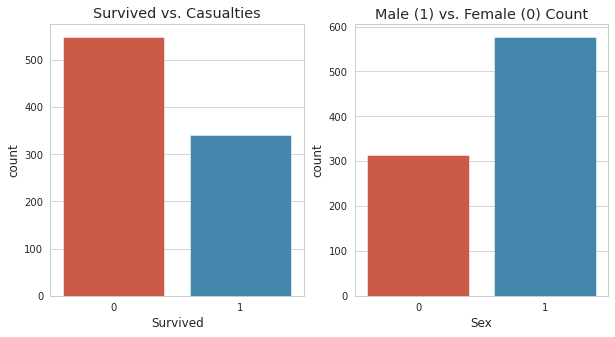

In [21]:
_, ax = plt.subplots(nrows=1, ncols=2, sharex=True, figsize=(10,5))

sns.countplot(x='Survived', data=train, ax=ax[0])
sns.countplot(x='Sex', data=train, ax=ax[1])

ax[0].set_title('Survived vs. Casualties')
ax[1].set_title('Male (1) vs. Female (0) Count')

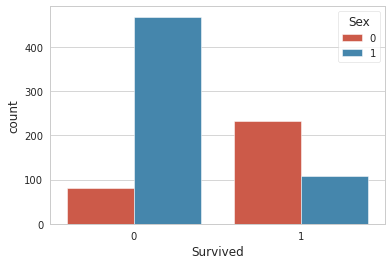

In [22]:
sns.countplot(x='Survived', data=train, hue='Sex')

In [23]:
# Lets check the percentage of people who survived

percentage_of_survived = 100 * (train['Survived'].value_counts() / train.shape[0])

# Percentage of Males who survivied
survived_male = train[(train['Survived']==1) & (train['Sex']==1)].shape[0]
total_male = train[train['Sex']==1].shape[0]

# Percentage of Females who survivied
survived_female = train[(train['Survived']==1) & (train['Sex']==0)].shape[0]
total_female = train[train['Sex']==0].shape[0]

print('Percentage of passngers in both target classes.')
print(percentage_of_survived)
print('-'*50)
print('Percentage of male passengers who survived: {:0.2f}'.format(100*(survived_male/total_male)))
print('Percentage of female passengers who survived: {:0.2f}'.format(100*(survived_female/total_female)))

Percentage of passngers in both target classes.
0    61.616162
1    38.383838
Name: Survived, dtype: float64
--------------------------------------------------
Percentage of male passengers who survived: 18.89
Percentage of female passengers who survived: 74.20


Text(0.5, 1.0, 'Passenger Class with respect to Survival')

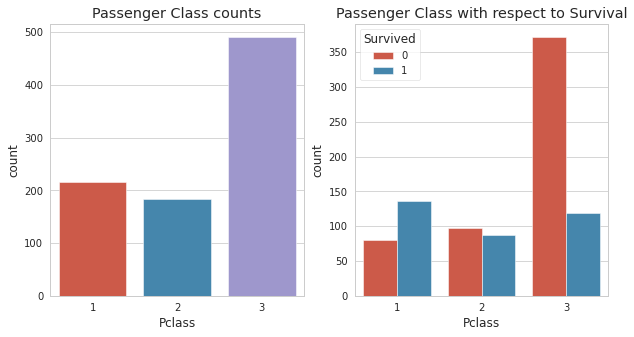

In [24]:
# Different passenger classes

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

sns.countplot(x='Pclass', data=train, ax=ax[0])
sns.countplot(x='Pclass', data=train, hue='Survived', ax=ax[1])

ax[0].set_title('Passenger Class counts')
ax[1].set_title('Passenger Class with respect to Survival')

Text(0.5, 1.0, 'Distribution of Fare')

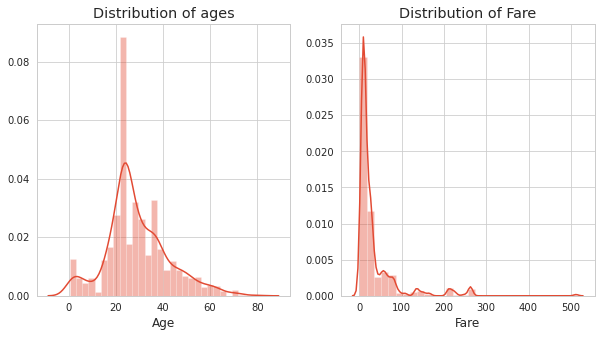

In [25]:
# Distributions of numerical columns and identification of ourliers

_, ax = plt.subplots(nrows=1, ncols=2, figsize=(10,5))

sns.distplot(train['Age'], bins=30, ax=ax[0])
ax[0].set_title('Distribution of ages')

sns.distplot(test['Fare'], bins=30, ax=ax[1])
ax[1].set_title('Distribution of Fare')

# Bivariate analysis

Bivariate analysis means the analysis of bivariate data. It is one of the simplest form of statistical analysis, used to find out if there is a relationship between two sets of values. It usually involves the variable X and Y.<br/>
Read more from the [source](https://www.statisticshowto.com/bivariate-analysis/)

Text(0.5, 1.0, 'Age vs. Fare w.r.t Survived')

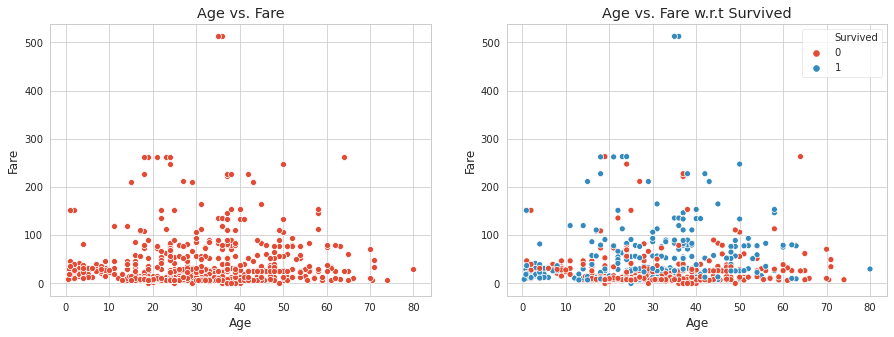

In [26]:
_, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,5))

sns.scatterplot(x='Age', y='Fare', data=train, ax=ax[0])
sns.scatterplot(x='Age', y='Fare', data=train, hue='Survived', ax=ax[1])

ax[0].set_title('Age vs. Fare')
ax[1].set_title('Age vs. Fare w.r.t Survived')

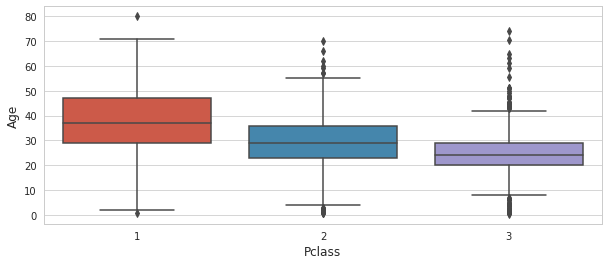

In [27]:
# Boxplot for Pclass vs age

plt.figure(figsize=(10, 4))
sns.boxplot(x='Pclass', y='Age', data=train)

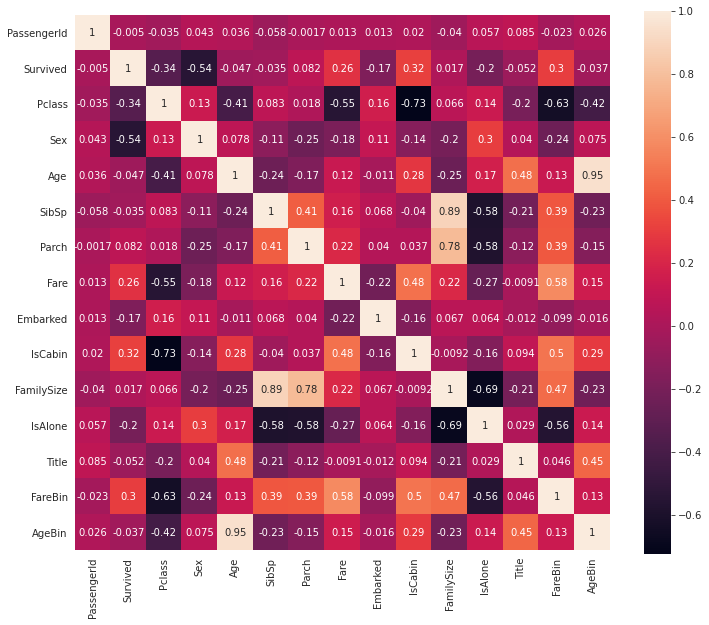

In [28]:
# Correlation

plt.figure(figsize=(12,10))
sns.heatmap(train.corr(), square=True, annot=True)

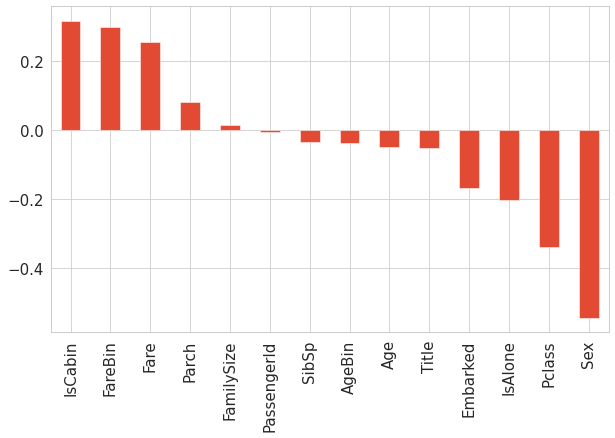

In [29]:
# How the independent variables are correlated with dependent

plt.figure(figsize=(10, 6))
train.corr().Survived.sort_values(ascending=False)[1:].plot(kind='bar',
                                                            fontsize=15)

In [30]:
# Final look at our dataset
train.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,IsCabin,FamilySize,IsAlone,Title,FareBin,AgeBin
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,NaN,2,0,2,0,2,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C85,0,1,2,0,3,3,2
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,NaN,2,0,1,1,1,1,1


# Predictive Modelling

## Necessary Imports

In [31]:
from scipy.stats import mode
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, GridSearchCV

In [32]:
# Creating X and y with only the training dataset for validation

remove_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin']
X = train.drop(
    labels=remove_cols,
    axis=1
)
y = train['Survived']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2)

# Shapes

print('X_train shape: {}'.format(X_train.shape))
print('y_train shape: {}'.format(y_train.shape))

print('X_test shape: {}'.format(X_test.shape))
print('y_test shape: {}'.format(y_test.shape))

X_train shape: (712, 13)
y_train shape: (712,)
X_test shape: (179, 13)
y_test shape: (179,)


In [33]:
# Method for handling trained model

def plt_conf_mat(y_true, y_pred, title):
    # Plotting confusion matrix
    
    plt.figure(figsize=(8,6))
    sns.heatmap(confusion_matrix(y_true, y_pred),
                annot=True,
                square=True)
    plt.xlabel('Predicted Class')
    plt.ylabel('Original Class')
    plt.title("{} Confusion Matrix".format(title))
    plt.show()

def model_data(trained_model, model_name, test_data=(X_test, y_test)):
    X_test, y_test = test_data
    prediction = trained_model.predict(X_test)
    accuracy = accuracy_score(y_test, prediction)
    
    # Output scores
    print('{} Accuracy: {}'.format(
        model_name, accuracy
    ))
    print('Classification Report')
    print('='*50)
    print(classification_report(y_test, prediction))
    
    plt_conf_mat(y_test, prediction, model_name)
    return accuracy, prediction

Simplest of the bunch
## Logistic Regression

Logistic Regression Accuracy: 0.7653631284916201
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       108
           1       0.71      0.69      0.70        71

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



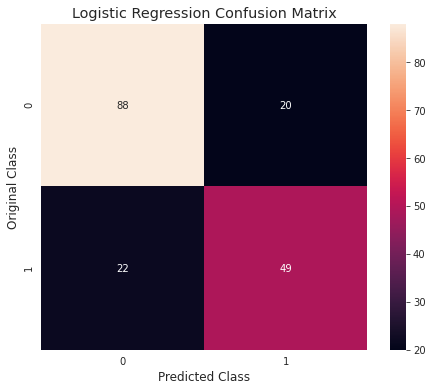

In [34]:
# Starting simple with Logistic Regression

logistic_regression = LogisticRegression()
logistic_regression.fit(X_train, y_train)

lr_acc, lr_pred = model_data(logistic_regression, 'Logistic Regression',
                             (X_test, y_test))

# Support Vector Classifier

**Looking for the best parameters using GridSearchCV**
Code for grid search:<br/>

```python
params = {
    'C':[0.001,0.01,0.1,1,10,100],
    'gamma': [0.01,0.1,1,10,100]
}

grid = GridSearchCV(SVC(), param_grid=params, verbose=.5, n_jobs=-1)
grid.fit(X_train, y_train)
```

**Ouput:**<br/>
```
GridSearchCV(cv=None, error_score=nan,
             estimator=SVC(C=1.0, break_ties=False, cache_size=200,
                           class_weight=None, coef0=0.0,
                           decision_function_shape='ovr', degree=3,
                           gamma='scale', kernel='rbf', max_iter=-1,
                           probability=False, random_state=None, shrinking=True,
                           tol=0.001, verbose=False),
             iid='deprecated', n_jobs=-1,
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10, 100],
                         'gamma': [0.01, 0.1, 1, 10, 100]},
             pre_dispatch='2*n_jobs', refit=True, return_train_score=False,
             scoring=None, verbose=0.5)
```

Best parameters turned out to be:<br/>

```
grid.best_params_
>>> {'C': 10, 'gamma': 0.01}
```

Support Vector Classifier Accuracy: 0.7653631284916201
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.81      0.81       108
           1       0.71      0.69      0.70        71

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.75       179
weighted avg       0.76      0.77      0.76       179



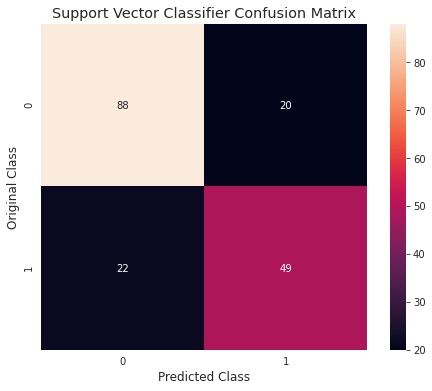

In [35]:
svc = SVC(C=10, gamma=0.01, kernel='rbf')
svc.fit(X_train, y_train)

svc_acc, svc_pred = model_data(svc, 'Support Vector Classifier',
                             (X_test, y_test))

# Decision Tree

**Looking for the best parameters using GridSearchCV**
Code for grid search:<br/>

```python
params = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [5,10,20,50,100],
    'min_samples_split': [2,5,10,15,20,30,40],
    'min_samples_leaf': [1,2,5,7,10,15,20,35,50]
}

grid = GridSearchCV(DecisionTreeClassifier(),
                    param_grid=params,
                    n_jobs=-1,
                    verbose=.5)

grid.fit(X_train, y_train)
```

Best parameters turned out to be:<br/>

```
grid.best_params_
>>> {'criterion': 'entropy',
     'max_depth': 10,
     'min_samples_leaf': 1,
     'min_samples_split': 10}
```

Decision Tree Classifier Accuracy: 0.8100558659217877
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.86      0.85       108
           1       0.78      0.73      0.75        71

    accuracy                           0.81       179
   macro avg       0.80      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



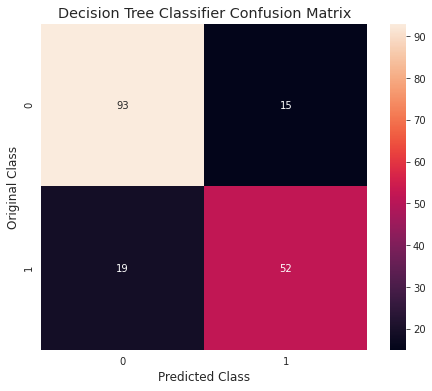

In [36]:
decision_tree = DecisionTreeClassifier(criterion='entropy',
                                       max_depth=10,
                                       min_samples_leaf=1,
                                       min_samples_split=20)
decision_tree.fit(X_train, y_train)

dtree_acc, dtree_pred = model_data(decision_tree, 
                                  'Decision Tree Classifier',
                                  (X_test, y_test))

# Random Forest

**Looking for the best parameters using GridSearchCV**
Code for grid search:<br/>

```python
params = {
    'n_estimators': [2,5,10,15,20,25,30],
    'criterion': ['gini', 'entropy'],
    'max_depth': [10,20,50,100,150,200,300,450,500],
    'min_samples_leaf': [1,3,5,10,15],
    'min_samples_split': [2,5,10,15,20,35,50]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid=params, verbose=.5, n_jobs=-1, cv=5)
grid.fit(X_train, y_train)
```

Best parameters turned out to be:<br/>

```
grid.best_params_
>>> {'criterion': 'entropy',
     'max_depth': 20,
     'min_samples_leaf': 1,
     'min_samples_split': 10,
     'n_estimators': 15}
```

Random Forest Classifier Accuracy: 0.8268156424581006
Classification Report
              precision    recall  f1-score   support

           0       0.83      0.89      0.86       108
           1       0.81      0.73      0.77        71

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.82       179
weighted avg       0.83      0.83      0.83       179



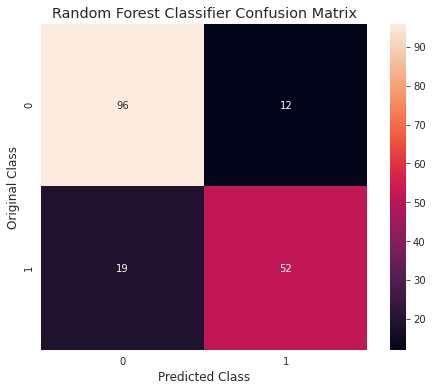

In [37]:
random_forest = RandomForestClassifier(criterion='entropy',
                                       max_depth=20,
                                       min_samples_leaf=1,
                                       min_samples_split=10,
                                       n_estimators=15)
random_forest.fit(X_train, y_train)

rf_acc, rf_pred = model_data(random_forest,
                             'Random Forest Classifier',
                             (X_test, y_test))

# Gradient Boosting

**Looking for the best parameters using GridSearchCV**
Code for grid search:<br/>

```python
params = {
    'n_estimators': [10,50,100,250,500,750,1000],
    'loss': ['deviance', 'exponential'],
    'learning_rate': [0.001, 0.01, 0.025, 0.05, 0.1, 0.5, 1],
    'subsample': [0.25, 1.0, 1.5],
    'criterion': ['friedman_mse', 'mse'],
    'min_samples_leaf': [2, 5, 9, 10]
}

grid = GridSearchCV(GradientBoostingClassifier(), param_grid=params, verbose=.5, n_jobs=-1, cv=5)
grid.fit(X_train, y_train)
```

Best parameters turned out to be:<br/>

```
grid.best_params_
>>> {'criterion': 'mse',
     'learning_rate': 0.025,
     'loss': 'exponential',
     'min_samples_leaf': 9,
     'n_estimators': 1000,
     'subsample': 0.25}
```

Gradient Boosting Classifier Accuracy: 0.7932960893854749
Classification Report
              precision    recall  f1-score   support

           0       0.80      0.88      0.84       108
           1       0.78      0.66      0.72        71

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179



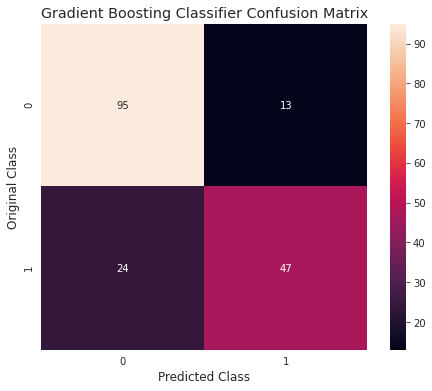

In [38]:
gradient_boosting = GradientBoostingClassifier(criterion='mse',
                                               learning_rate=0.025,
                                               min_samples_leaf=9,
                                               n_estimators=1000,
                                               max_depth=3,
                                               subsample=0.25)

gradient_boosting.fit(X_train, y_train)

gb_acc, gb_pred = model_data(gradient_boosting,
                             'Gradient Boosting Classifier',
                             (X_test, y_test))

# Max Voting

Max-voting, which is generally used for classification problems, is one of the simplest ways of combining predictions from multiple machine learning algorithms. In max-voting, each base model makse a prediction and votes for each sample. One the sample class with the highest votes is included in the final predictive class.<br/>

Scikit-Learn already has the `sklearn.ensemble.VotingClassifier`, where in the `voting` argument we can give one of two values `hard`, `soft` (defaults to `hard`). If 'hard', the classifier uses predicted class labels for majority rule voting. Else if 'soft', predicts the class label based on the argmax of the sums of the predicted probabilities, which is recommended for an ensemble of well-calibrated classifiers. But here, we are doing things manually ('hard' voting)<br/>

Read more about the class from scikit-learns [documentation](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.VotingClassifier.html).

### Using DecisionTree, RandomForest, GradientBoosting Classifiers

In [39]:
# Lets first create a dataframe 

predictions = pd.DataFrame(columns=['DecisionTree',
                                    'RandomForest',
                                    'GradientBoosting'])
predictions['DecisionTree'] = dtree_pred
predictions['RandomForest'] = rf_pred
predictions['GradientBoosting'] = gb_pred

# Lets take a look at the end of the dataframe
predictions.head()

,DecisionTree,RandomForest,GradientBoosting
0,1,1,1
1,0,0,0
2,1,1,1
3,0,0,0
4,1,1,1


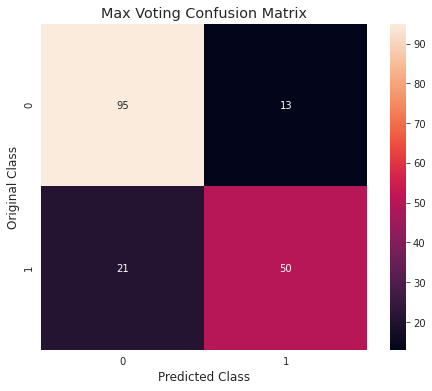

Accuracy: 0.8100558659217877
Classification Report
              precision    recall  f1-score   support

           0       0.82      0.88      0.85       108
           1       0.79      0.70      0.75        71

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.80       179
weighted avg       0.81      0.81      0.81       179



In [40]:
final_predictions = []
for preds in predictions.iterrows():
    final_predictions.append(mode(preds[1].values)[0][0])
    
plt_conf_mat(y_test, final_predictions, 'Max Voting')
print('Accuracy: {}'.format(accuracy_score(y_test, final_predictions)))
print('Classification Report')
print('='*50)
print(classification_report(y_test, final_predictions))

# Training with the entire dataset and creating result

In [41]:
remove_cols = ['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin']
X_train = train.drop(
          labels=remove_cols,
          axis=1
        )
y_train = train['Survived']

remove_cols.remove('Survived')
X_test = test.drop(
        labels=remove_cols,
        axis=1
)

In [42]:
# Shapes

print('X_train shape: {}'.format(X_train.shape))
print('X_test shape: {}'.format(X_test.shape))
print('y_train shape: {}'.format(y_train.shape))

X_train shape: (891, 13)
X_test shape: (418, 13)
y_train shape: (891,)


In [43]:
# Training the models

decision_tree = DecisionTreeClassifier(criterion='entropy',
                                       max_depth=10,
                                       min_samples_leaf=1,
                                       min_samples_split=20)
random_forest = RandomForestClassifier(criterion='entropy',
                                       max_depth=200,
                                       min_samples_leaf=1,
                                       min_samples_split=10,
                                       n_estimators=15)
gradient_boosting = GradientBoostingClassifier(criterion='mse',
                                               learning_rate=0.025,
                                               min_samples_leaf=9,
                                               n_estimators=1000,
                                               max_depth=3,
                                               subsample=0.25)

model_preds = []

for model in [decision_tree, random_forest, gradient_boosting]:
    model.fit(X_train, y_train)
    model_preds.append(model.predict(X_test))
    
# Max voting
max_voting_pred = []
for row in np.array(model_preds).T:
    max_voting_pred.append(mode(row)[0][0])

# Submission

In [44]:
submission = pd.DataFrame(data={
    'PassengerId': test['PassengerId'],
    'Survived': model_preds[2]
})
submission.tail(5)

,PassengerId,Survived
413,1305,0
414,1306,1
415,1307,0
416,1308,0
417,1309,1


In [45]:
# submission.to_csv('submission.csv', index=False)

# References

* https://stats.idre.ucla.edu/other/mult-pkg/whatstat/what-is-the-difference-between-categorical-ordinal-and-numerical-variables/
* https://en.wikipedia.org/wiki/Data_exploration
* https://stats.oecd.org/glossary/detail.asp?ID=3462ome ama
* https://www.statisticshowto.com/bivariate-analysis/

## Some amazing notebooks for this dataset

* https://www.kaggle.com/ldfreeman3/a-data-science-framework-to-achieve-99-accuracy
* https://www.kaggle.com/gunesevitan/titanic-advanced-feature-engineering-tutorial
* https://www.kaggle.com/masumrumi/a-statistical-analysis-ml-workflow-of-titanic

### Thank you so much for the view! 